In [2]:
#1...
%pip install -q pandas numpy scikit-learn joblib torch transformers sentencepiece
%pip install imbalanced-learn
print("Packages ready: pandas, numpy, scikit-learn, joblib, torch, transformers")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Packages ready: pandas, numpy, scikit-learn, joblib, torch, transformers


In [3]:
#2...
import json
import re
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from transformers import AutoModel, AutoTokenizer

RANDOM_STATE = 42
DATA_DIR = Path("data")
OUTPUT_DIR = DATA_DIR / "commentshield_final_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MAX_COMMENTS = 2000
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.10
LABELS = ["Moderation Required", "Reply Required", "Low Priority"]
MAX_LENGTH = 128
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TAMIL_FILE = DATA_DIR / "tamil_tanglish" / "cleaned_comments_no_author.csv"
ENGLISH_FILE = DATA_DIR / "english" / "YouTube Comments Dataset with Sentiment Toxicity and Spam Labels (45K Rows).csv"

if not TAMIL_FILE.exists():
    raise FileNotFoundError(f"Tamil/Tanglish file not found: {TAMIL_FILE.resolve()}")
if not ENGLISH_FILE.exists():
    raise FileNotFoundError(f"English file not found: {ENGLISH_FILE.resolve()}")

print("Fixed comment limit:", MAX_COMMENTS)

Fixed comment limit: 2000


In [ ]:
#3...
tamil_raw = pd.read_csv(TAMIL_FILE)
english_raw = pd.read_csv(ENGLISH_FILE)


def find_column(frame, names, dataset_name):
    for name in names:
        if name in frame.columns:
            return name
    raise ValueError(f"No comment column found in {dataset_name}. Columns: {list(frame.columns)}")


def normalize_text(value):
    if pd.isna(value):
        return ""
    text = str(value).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text )
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


tamil_col = find_column(tamil_raw, ["cleaned_text", "comment", "text", "comment_text"], "Tamil/Tanglish")
english_col = find_column(english_raw, ["comment_text", "comment", "text", "cleaned_text"], "English")

all_comments = pd.concat([
    pd.DataFrame({"comment": tamil_raw[tamil_col]}),
    pd.DataFrame({"comment": english_raw[english_col]}),
], ignore_index=True)

all_comments["comment"] = all_comments["comment"].map(normalize_text).astype("object")
all_comments = all_comments[all_comments["comment"].map(len) >= 3]
all_comments = all_comments.drop_duplicates("comment").reset_index(drop=True)

if len(all_comments) < MAX_COMMENTS:
    raise ValueError(f"Only {len(all_comments)} unique comments available; need {MAX_COMMENTS}.")

sampled_comments = all_comments.sample(n=MAX_COMMENTS, random_state=RANDOM_STATE).reset_index(drop=True)
sampled_comments.insert(0, "comment_id", np.arange(1, len(sampled_comments) + 1))

print("Dataset cleaning completed")
print("Rows available for modelling:", len(sampled_comments))

Dataset cleaning completed
Rows available for modelling: 2000


In [5]:
#4...
QUESTION_WORDS = ["why", "what", "how", "when", "where", "which", "who", "எப்படி", "என்ன", "ஏன்", "yenna", "enna", "eppo", "epdi", "epadi", "yaru", "yaaru", "edhuku", "ethuku"]
REQUEST_WORDS = ["please", "explain", "tell me", "suggest", "recommend", "show me", "give me", "upload", "share", "help", "வேண்டும்", "சொல்லுங்கள்", "விளக்குங்கள்", "கொடுங்கள்", "plz", "pls", "venum", "vendum", "kudunga", "kudu", "sollu", "sollunga", "koncham"]
CORRECTION_WORDS = ["wrong", "incorrect", "mistake", "actually", "fake", "false", "not true", "fix this", "change this", "not correct", "தவறு", "தவறான", "சரி இல்லை", "மாற்றுங்கள்", "thappu", "thappana", "correct pannunga", "fake news", "poi"]
TOXICITY_WORDS = ["stupid", "idiot", "bastard", "moron", "dumb", "loser", "shut up", "hate you", "get lost", "பைத்தியம்", "முட்டாள்", "லூசு", "punda", "otha", "koothi", "myirey", "thevidiya", "naaye"]


def keyword_exists(text, keyword):
    text, keyword = str(text).lower(), str(keyword).lower().strip()
    if not keyword:
        return False
    if any("\u0B80" <= char <= "\u0BFF" for char in keyword):
        return keyword in text
    return re.search(r"(?<![A-Za-z])" + re.escape(keyword) + r"(?![A-Za-z])", text) is not None


def count_matches(text, words):
    return sum(keyword_exists(text, word) for word in words)


def count_tamil_chars(text):
    return sum("\u0B80" <= char <= "\u0BFF" for char in str(text))


def count_english_chars(text):
    return sum(("A" <= char <= "Z") or ("a" <= char <= "z") for char in str(text))


features = sampled_comments.copy()
features["comment_length"] = features["comment"].map(len)
features["word_count"] = features["comment"].map(lambda text: len(str(text).split()))
features["question_signal"] = features["comment"].map(lambda text: int("?" in text) + count_matches(text, QUESTION_WORDS))
features["request_signal"] = features["comment"].map(lambda text: count_matches(text, REQUEST_WORDS))
features["correction_signal"] = features["comment"].map(lambda text: count_matches(text, CORRECTION_WORDS))
features["toxicity_score"] = features["comment"].map(lambda text: count_matches(text, TOXICITY_WORDS))
features["tamil_char_count"] = features["comment"].map(count_tamil_chars)
features["english_char_count"] = features["comment"].map(count_english_chars)
features["tamil_script_ratio"] = features["tamil_char_count"] / features["comment_length"].clip(lower=1)
features["english_script_ratio"] = features["english_char_count"] / features["comment_length"].clip(lower=1)
features["code_mixed_signal"] = ((features["tamil_char_count"] > 0) & (features["english_char_count"] > 0)).astype(int)


def make_proxy_label(row):
    if row["toxicity_score"] > 0:
        return "Moderation Required"
    if row["question_signal"] > 0 or row["request_signal"] > 0 or row["correction_signal"] > 0:
        return "Reply Required"
    return "Low Priority"


features["proxy_label"] = features.apply(make_proxy_label, axis=1)

# Select the same ten real comments for Cell 10 in fixed priority order.
priority_order = ["Moderation Required", "Reply Required", "Low Priority"]
priority_counts = {
    "Moderation Required": 3,
    "Reply Required": 3,
    "Low Priority": 4,
}

selected_parts = []
for label in priority_order:
    selected_parts.append(features[features["proxy_label"] == label].head(priority_counts[label]))

demo_comments = pd.concat(selected_parts, ignore_index=False)
remaining = features[~features["comment_id"].isin(demo_comments["comment_id"])].head(
    max(0, 10 - len(demo_comments))
)
demo_comments = pd.concat([demo_comments, remaining], ignore_index=False).head(10).copy()
demo_comments["priority_order"] = pd.Categorical(
    demo_comments["proxy_label"],
    categories=priority_order,
    ordered=True,
)
demo_comments = demo_comments.sort_values(
    ["priority_order", "comment_id"]
).reset_index(drop=True)


def signal_name(row):
    if row["toxicity_score"] > 0:
        return "Toxicity"
    if row["question_signal"] > 0:
        return "Question"
    if row["request_signal"] > 0:
        return "Request"
    if row["correction_signal"] > 0:
        return "Correction"
    return "No strong signal"


def mask_toxic_text(text):
    masked = str(text)
    for word in TOXICITY_WORDS:
        word = str(word).strip()
        if not word:
            continue
        if any("\u0B80" <= char <= "\u0BFF" for char in word):
            masked = masked.replace(word, "[masked]")
        else:
            pattern = r"(?<![A-Za-z])" + re.escape(word) + r"(?![A-Za-z])"
            masked = re.sub(pattern, "[masked]", masked, flags=re.IGNORECASE)
    return masked


# Display-only copy; original features text remains unchanged for modelling.
display_examples = demo_comments[["comment_id", "comment", "proxy_label"]].copy()
display_examples["Signal"] = demo_comments.apply(signal_name, axis=1).to_numpy()
display_examples = display_examples.rename(columns={
    "comment_id": "Comment ID",
    "comment": "Comment",
    "proxy_label": "Priority",
})
display_examples["Comment"] = display_examples.apply(
    lambda row: mask_toxic_text(row["Comment"])
    if row["Priority"] == "Moderation Required"
    else row["Comment"],
    axis=1,
)
display_examples = display_examples[["Comment ID", "Comment", "Signal", "Priority"]]

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 20)
print("Feature table:", features.shape)
print("Proxy labels created:", features["proxy_label"].nunique())
print("Signal and priority examples")
display(display_examples)


Feature table: (2000, 14)
Proxy labels created: 3
Signal and priority examples


,Comment ID,Comment,Signal,Priority
0,207,"பிராந்தி கடைகளை அடைகிற வரை சட்டவிரோத செயல்கள் குறைய போவது இல்லை. மக்களை குறிப்பாக இளைஞர்களை போதையில் மிதக்க விட்டு அறிவு கெட்டவர்களாக ஆக்கி , அரசியல்வாதிகள் 10:20 தலைமுறைக்கு சொத்து சேர்த்து சந்தோசமாக வாழ்வார்கள. மக்கள் [masked]களாக மடிவார்கள்.",Toxicity,Moderation Required
1,251,shameless [masked] people used this animal,Toxicity,Moderation Required
2,762,[masked] daii idhu romba mukiyama,Toxicity,Moderation Required
3,10,"anand andhra movie tamil person, youre not understand, thats why you dont see movie, its andhra pushpa pushpa raj, its andhra",Question,Reply Required
4,15,varanda race pakam poirurathinga makle fake institute money vangitu kanduka matanaga,Correction,Reply Required
5,17,how to stop night feeding and make baby forget during hungry in sleeping time,Question,Reply Required
6,1,very good condition to you,No strong signal,Low Priority
7,2,me as trans guy trying to make my voice deeper no borax no glue,No strong signal,Low Priority
8,3,nice nail polish madam,No strong signal,Low Priority
9,4,சனன கலலனன சலலஙக ட,No strong signal,Low Priority


In [6]:
#5...
# Signals and features were created in Cell 4.
print("Signals ready for modelling")
print("Rows available:", len(features))
print("Labels available:", features["proxy_label"].nunique())

Signals ready for modelling
Rows available: 2000
Labels available: 3


In [7]:
#6...
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

train_valid, test_df = train_test_split(
    features,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=features["proxy_label"],
)

validation_fraction = VALIDATION_SIZE / (1 - TEST_SIZE)
train_df, validation_df = train_test_split(
    train_valid,
    test_size=validation_fraction,
    random_state=RANDOM_STATE,
    stratify=train_valid["proxy_label"],
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


def metrics_for(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        labels=LABELS,
        output_dict=True,
        zero_division=0,
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "macro_precision": float(report["macro avg"]["precision"]),
        "macro_recall": float(report["macro avg"]["recall"]),
        "moderation_recall": float(report["Moderation Required"]["recall"]),
        "report": report,
        "confusion_matrix": confusion_matrix(
            y_true,
            y_pred,
            labels=LABELS,
        ).tolist(),
    }


y_train = train_df["proxy_label"].to_numpy()
y_validation = validation_df["proxy_label"].to_numpy()
y_test = test_df["proxy_label"].to_numpy()

split_table = pd.DataFrame({
    "Model": ["TF-IDF", "MiniLM"],
    "Train comments": [len(train_df), len(train_df)],
    "Validation comments": [len(validation_df), len(validation_df)],
    "Test comments": [len(test_df), len(test_df)],
    "Split": ["70% / 10% / 20%", "70% / 10% / 20%"],
})

print("Same train-validation-test split used for both models")
display(split_table)

Same train-validation-test split used for both models


,Model,Train comments,Validation comments,Test comments,Split
0,TF-IDF,1400,200,400,70% / 10% / 20%
1,MiniLM,1400,200,400,70% / 10% / 20%


In [8]:
#  7: DIRECT SPARSE VECTOR PATHWAY WITHOUT SVD ---
tfidf = TfidfVectorizer(analyzer="char", ngram_range=(3, 5), min_df=2, max_features=3000, sublinear_tf=True)

# 1. SVD இல்லாமல் நேரடியாக TF-IDF மேட்ரிக்ஸை அடர்ந்த அணியாக (Dense Array) மாற்றி சிக்னலை காப்பாற்றுகிறோம்
X_train_tfidf_final = tfidf.fit_transform(train_df["comment"]).toarray()
X_validation_tfidf = tfidf.transform(validation_df["comment"]).toarray()
X_test_tfidf = tfidf.transform(test_df["comment"]).toarray()
X_all_tfidf = tfidf.transform(features["comment"]).toarray()

def train_hgb(X_train, X_validation, X_test, y_train, y_validation, y_test):
    model = HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=100,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train, sample_weight=compute_sample_weight("balanced", y_train))
    validation_pred = model.predict(X_validation)
    test_pred = model.predict(X_test)
    return model, validation_pred, test_pred, metrics_for(y_validation, validation_pred), metrics_for(y_test, test_pred)

tfidf_model, tfidf_validation_pred, tfidf_test_pred, tfidf_validation_metrics, tfidf_test_metrics = train_hgb(
    X_train_tfidf_final, X_validation_tfidf, X_test_tfidf, y_train, y_validation, y_test
)

print("TF-IDF baseline trained without SVD compression!")
print("Validation Macro-F1:", round(tfidf_validation_metrics["macro_f1"], 4))
print("Test Macro-F1:", round(tfidf_test_metrics["macro_f1"], 4))
print("Test Moderation Recall:", round(tfidf_test_metrics["moderation_recall"], 4))


TF-IDF baseline trained without SVD compression!
Validation Macro-F1: 0.5311
Test Macro-F1: 0.5325
Test Moderation Recall: 0.0


In [9]:
#8...
import time
from pathlib import Path


import numpy as np
import torch
from transformers import AutoModel, AutoTokenizer

if "features" not in globals():
    raise RuntimeError("Run Cells 3–7 first. The features table is missing.")

LOCAL_MINILM_PATH = Path.home() / "Documents" / "HFModels" / "MiniLM"
if not LOCAL_MINILM_PATH.exists():
    raise FileNotFoundError(
        f"Local MiniLM folder not found: {LOCAL_MINILM_PATH}"
    )

# Use the existing settings from Cell 2 when available.
MAX_LENGTH = globals().get("MAX_LENGTH", 128)
BATCH_SIZE = globals().get("BATCH_SIZE", 16)

started = time.time()
tokenizer = AutoTokenizer.from_pretrained(
    str(LOCAL_MINILM_PATH),
    local_files_only=True,
)
encoder = AutoModel.from_pretrained(
    str(LOCAL_MINILM_PATH),
    local_files_only=True,
)
encoder.eval()

all_texts = features["comment"].astype(str).tolist()
embedding_batches = []

# No tqdm/progress widget is used, so repeated Processed... lines and
# application/vnd.jupyter.widget-view+json messages are avoided.
for start in range(0, len(all_texts), BATCH_SIZE):
    batch = all_texts[start:start + BATCH_SIZE]
    tokens = tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    with torch.no_grad():
        output = encoder(**tokens)
        attention_mask = tokens["attention_mask"].unsqueeze(-1).float()
        pooled = (
            (output.last_hidden_state * attention_mask).sum(dim=1)
            / attention_mask.sum(dim=1).clamp(min=1e-9)
        )

    embedding_batches.append(pooled.cpu().numpy().astype(np.float32))

minilm_embeddings = np.vstack(embedding_batches)
transformer_embeddings = {"MiniLM": minilm_embeddings}
embedding_seconds = time.time() - started

del encoder, tokenizer

print("MiniLM embedding generation completed")
print("Comments encoded:", minilm_embeddings.shape[0])
print("Embedding dimension:", minilm_embeddings.shape[1])
print(f"Embedding time (seconds): {embedding_seconds:.2f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MiniLM embedding generation completed
Comments encoded: 2000
Embedding dimension: 384
Embedding time (seconds): 318.32


In [ ]:
# --- PART 9: EXTENDED ACCURATE PIPELINE EVALUATION AND FIX ---
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import numpy as np

# Step 1: y_all — features dataframe irunthu edukurom
y_all = features["proxy_label"].to_numpy()

# Step 2: train/validation/test positions — Cell 6-la already split aacchu!
# So same indices use pannuvom
train_pos = train_df.index.to_numpy()
validation_pos = validation_df.index.to_numpy()
test_pos = test_df.index.to_numpy()

# Step 3: fit_and_score function
def fit_and_score(name, X_train, X_validation, X_test):
    classifier = HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.1,
        random_state=RANDOM_STATE
    )

    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=1)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

    balanced_weights = compute_sample_weight(class_weight="balanced", y=y_train_balanced)
    classifier.fit(X_train_balanced, y_train_balanced, sample_weight=balanced_weights)

    validation_pred = classifier.predict(X_validation)
    test_pred = classifier.predict(X_test)

    validation_f1 = precision_recall_fscore_support(
        y_validation, validation_pred, labels=LABELS, average="macro", zero_division=0
    )[2]
    test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
        y_test, test_pred, labels=LABELS, average="macro", zero_division=0
    )

    return {
        "name": name,
        "classifier": classifier,
        "validation_macro_f1": float(validation_f1),
        "test_accuracy": float(accuracy_score(y_test, test_pred)),
        "test_macro_precision": float(test_precision),
        "test_macro_recall": float(test_recall),
        "test_macro_f1": float(test_f1),
        "test_predictions": test_pred,
        "test_confusion_matrix": confusion_matrix(y_test, test_pred, labels=LABELS),
    }

# Step 4: MiniLM train/val/test split pannunga
minilm_all = transformer_embeddings["MiniLM"]
train_indices = train_df.index.tolist()
validation_indices = validation_df.index.tolist()
test_indices = test_df.index.tolist()

X_train_minilm = minilm_all[train_indices]
X_validation_minilm = minilm_all[validation_indices]
X_test_minilm = minilm_all[test_indices]

# Step 5: Models run pannunga
model_artifacts = {}
model_artifacts["TF-IDF"] = fit_and_score("TF-IDF", X_train_tfidf_final, X_validation_tfidf, X_test_tfidf)
model_artifacts["MiniLM"] = fit_and_score("MiniLM", X_train_minilm, X_validation_minilm, X_test_minilm)

# Step 6: Results display pannunga
comparison_rows = []
for name, result in model_artifacts.items():
    comparison_rows.append({
        "Model": name,
        "Validation Macro-F1": round(result["validation_macro_f1"], 4),
        "Test Accuracy": round(result["test_accuracy"], 4),
        "Test Macro-Precision": round(result["test_macro_precision"], 4),
        "Test Macro-Recall": round(result["test_macro_recall"], 4),
        "Test Macro-F1": round(result["test_macro_f1"], 4),
    })

comparison_table = pd.DataFrame(comparison_rows).sort_values(
    "Validation Macro-F1", ascending=False).reset_index(drop=True)
best_model_name = comparison_table.loc[0, "Model"]
selected_model = model_artifacts[best_model_name]["classifier"]

print("=== PIPELINE OPTIMIZATION COMPLETE ===")
display(comparison_table)

cm = model_artifacts[best_model_name]["test_confusion_matrix"]
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual: {l}" for l in LABELS],
    columns=[f"Predicted: {l}" for l in LABELS]
)
print(f"\nConfusion Matrix for Best Model ({best_model_name}):")
display(cm_df)

NameError: name 'original_df' is not defined

In [ ]:
#10
from pathlib import Path
import numpy as np
import pandas as pd

required = [
    "features", "model_artifacts", "X_all_tfidf",
    "transformer_embeddings", "id_to_position", "LABELS",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run earlier cells first. Missing: {missing}")

output_dir = Path(DATA_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

tfidf_model = model_artifacts["TF-IDF"]["classifier"]
minilm_model = model_artifacts["MiniLM"]["classifier"]

tfidf_classes = list(tfidf_model.classes_)
minilm_classes = list(minilm_model.classes_)

def probability_for(probabilities, classes, label):
    if label not in classes:
        return 0.0
    return float(probabilities[classes.index(label)])

def safe_signal(row, name):
    value = row.get(name, 0.0)
    try:
        return float(value) if pd.notna(value) else 0.0
    except (TypeError, ValueError):
        return 0.0

def explanation(row):
    reasons = []
    if safe_signal(row, "toxicity_score") > 0:
        reasons.append("Toxicity-related signal detected; requires human moderation review.")
    if safe_signal(row, "question_signal") > 0:
        reasons.append("Question signal detected; creator response may be required.")
    if safe_signal(row, "request_signal") > 0:
        reasons.append("Request signal detected; creator response may be required.")
    if safe_signal(row, "correction_signal") > 0:
        reasons.append("Correction signal detected.")
    return " ".join(reasons) if reasons else "No strong intervention signal detected."

all_ids = features["comment_id"].astype(int).to_numpy()
all_positions = np.array([id_to_position[int(cid)] for cid in all_ids])

tfidf_features_all = X_all_tfidf[all_positions]
minilm_features_all = transformer_embeddings["MiniLM"][all_positions]

tfidf_probs_all = tfidf_model.predict_proba(tfidf_features_all)
minilm_probs_all = minilm_model.predict_proba(minilm_features_all)
tfidf_preds_all = tfidf_model.predict(tfidf_features_all)

rows = []
for i, (_, feature_row) in enumerate(features.iterrows()):

    predicted_priority = str(tfidf_preds_all[i])

    moderation_probability = probability_for(tfidf_probs_all[i], tfidf_classes, "Moderation Required")
    reply_probability = probability_for(tfidf_probs_all[i], tfidf_classes, "Reply Required")
    low_probability = probability_for(tfidf_probs_all[i], tfidf_classes, "Low Priority")

    urgency_score = float(np.clip(
        moderation_probability + 0.65 * reply_probability + 0.10 * low_probability,
        0.0, 1.0,
    ))

    tfidf_score = probability_for(tfidf_probs_all[i], tfidf_classes, predicted_priority)
    minilm_score = probability_for(minilm_probs_all[i], minilm_classes, predicted_priority)

    rows.append({
        "comment": str(feature_row["comment"]),
        "actual_label": str(feature_row["proxy_label"]),
        "predicted_label": predicted_priority,
        "Moderation Required_probability": round(moderation_probability, 4),
        "Reply Required_probability": round(reply_probability, 4),
        "Low Priority_probability": round(low_probability, 4),
        "urgency_score": round(urgency_score, 4),
        "TF-IDF Score": round(tfidf_score, 4),
        "MiniLM Score": round(minilm_score, 4),
        "Explanation": explanation(feature_row),
    })

ranked_full = pd.DataFrame(rows).sort_values(
    "urgency_score", ascending=False
).reset_index(drop=True)

ranked_200 = ranked_full.head(200).copy()
ranked_200.insert(0, "queue_rank", np.arange(1, len(ranked_200) + 1))

ranked_200.to_csv(output_dir / "ranked_predictions_hgb.csv", index=False)

print("Saved:", output_dir / "ranked_predictions_hgb.csv")
print("Rows:", len(ranked_200))

# --- clean table display ---
pd.set_option("display.max_colwidth", 60)   # comment column trim
pd.set_option("display.width", 150)         # avoid wrap-around

preview_cols = [
    "queue_rank", "comment", "actual_label", "predicted_label",
    "TF-IDF Score", "MiniLM Score", "urgency_score", "Explanation",
]

try:
    from IPython.display import display
    display(ranked_200[preview_cols].head(10))
except ImportError:
    print(ranked_200[preview_cols].head(10).to_string(index=False))

Saved: data\ranked_predictions_hgb.csv
Rows: 200


,queue_rank,comment,actual_label,predicted_label,TF-IDF Score,MiniLM Score,urgency_score,Explanation
0,1,how does he know iran don't have another cave under a to...,Moderation Required,Moderation Required,1.0000,1.0,1.0000,Toxicity-related signal detected; requires human moderat...
1,2,dont believe everything what this idiot saysthis guy cle...,Moderation Required,Moderation Required,1.0000,1.0,1.0000,Toxicity-related signal detected; requires human moderat...
2,3,time for break such stupid concept being claimed finance...,Moderation Required,Moderation Required,0.9999,1.0,0.9999,Toxicity-related signal detected; requires human moderat...
3,4,"even if apple did sell the batteries, still giving them ...",Moderation Required,Moderation Required,0.9999,1.0,0.9999,Toxicity-related signal detected; requires human moderat...
4,5,shameless bastard people used this animal,Moderation Required,Moderation Required,0.9998,1.0,0.9998,Toxicity-related signal detected; requires human moderat...
5,6,dai vara vala paru da punda,Moderation Required,Moderation Required,0.9997,1.0,0.9998,Toxicity-related signal detected; requires human moderat...
6,7,பிராந்தி கடைகளை அடைகிற வரை சட்டவிரோத செயல்கள் குறைய போவத...,Moderation Required,Moderation Required,0.9994,1.0,0.9995,Toxicity-related signal detected; requires human moderat...
7,8,vishall pls vote,Reply Required,Reply Required,1.0000,1.0,0.6500,Request signal detected; creator response may be required.
8,9,what do do if my friends made me inhale bunch of baby po...,Reply Required,Reply Required,1.0000,1.0,0.6500,Question signal detected; creator response may be requir...
9,10,"for tamilians, listening to malayalam is like dialect of...",Reply Required,Reply Required,1.0000,1.0,0.6500,Question signal detected; creator response may be requir...


In [ ]:
# --- FULL INGESTION QUEUE CONFUSION MATRIX (2,000 COMMENTS) ---
from sklearn.metrics import confusion_matrix
import pandas as pd
from IPython.display import display

# Computing global ingestion tracking metrics directly using compiled dataframe records
full_cm = confusion_matrix(
    ranked_full["actual_label"], 
    ranked_full["predicted_label"], 
    labels=LABELS
)

# Generating verified summary dataframe table layout mapping configs
full_cm_df = pd.DataFrame(
    full_cm, 
    index=[f"Actual: {l}" for l in LABELS], 
    columns=[f"Predicted: {l}" for l in LABELS]
)

print("=== GLOBAL INGESTION QUEUE CONFUSION MATRIX ===")
display(full_cm_df)


=== GLOBAL INGESTION QUEUE CONFUSION MATRIX ===


,Predicted: Moderation Required,Predicted: Reply Required,Predicted: Low Priority
Actual: Moderation Required,7,0,3
Actual: Reply Required,0,288,37
Actual: Low Priority,0,17,1648


In [ ]:
#11....
from pathlib import Path
from IPython.display import HTML, display

required = [
    "features",
    "demo_comments",
    "best_model_name",
    "selected_model",
    "selected_all_features",
    "id_to_position",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run Cells 1–9 first. Missing variables: {missing}")

output_dir = Path(DATA_DIR) / "commentshield_final_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

demo_ids = demo_comments["comment_id"].astype(int).to_numpy()
demo_positions = np.array([id_to_position[int(cid)] for cid in demo_ids])
demo_features = selected_all_features[demo_positions]
demo_predictions = selected_model.predict(demo_features)
demo_probabilities = selected_model.predict_proba(demo_features)
class_order = list(selected_model.classes_)


def probability_for(probabilities, label):
    if label not in class_order:
        return 0.0
    return float(probabilities[class_order.index(label)])


def safe_signal(row, name):
    value = row.get(name, 0.0)
    try:
        return float(value) if pd.notna(value) else 0.0
    except (TypeError, ValueError):
        return 0.0


def explanation(row):
    reasons = []
    if safe_signal(row, "toxicity_score") > 0:
        reasons.append("toxicity signal")
    if safe_signal(row, "question_signal") > 0:
        reasons.append("question signal")
    if safe_signal(row, "request_signal") > 0:
        reasons.append("request signal")
    if safe_signal(row, "correction_signal") > 0:
        reasons.append("correction signal")
    return ", ".join(reasons) if reasons else "no strong rule signal"


def mask_toxic_text(text):
    masked = str(text)
    for word in TOXICITY_WORDS:
        word = str(word).strip()
        if not word:
            continue
        if any("\u0B80" <= char <= "\u0BFF" for char in word):
            masked = masked.replace(word, "[masked]")
        else:
            pattern = r"(?<![A-Za-z])" + re.escape(word) + r"(?![A-Za-z])"
            masked = re.sub(pattern, "[masked]", masked, flags=re.IGNORECASE)
    return masked


ranked_rows = []
for position, (_, demo_row) in enumerate(demo_comments.iterrows()):
    feature_row = features.iloc[demo_positions[position]]
    predicted_priority = str(demo_predictions[position])
    probabilities = demo_probabilities[position]
    model_score = probability_for(probabilities, predicted_priority)
    moderation_probability = probability_for(probabilities, "Moderation Required")
    reply_probability = probability_for(probabilities, "Reply Required")
    low_probability = probability_for(probabilities, "Low Priority")
    urgency_score = float(np.clip(
        moderation_probability + 0.65 * reply_probability + 0.10 * low_probability,
        0.0,
        1.0,
    ))

    reference_priority = str(demo_row["proxy_label"])
    visible_comment = str(demo_row["comment"])
    if reference_priority == "Moderation Required":
        visible_comment = mask_toxic_text(visible_comment)

    ranked_rows.append({
        "Rank": 0,
        "Comment ID": int(demo_row["comment_id"]),
        "Comment": visible_comment,
        "Reference Priority": reference_priority,
        "Predicted Priority": predicted_priority,
        "Model Score": round(model_score, 4),
        "Urgency Score": round(urgency_score, 4),
        "Explanation": explanation(feature_row),
    })

ranked_demo = pd.DataFrame(ranked_rows).sort_values(
    "Urgency Score", ascending=False
).reset_index(drop=True)
ranked_demo["Rank"] = np.arange(1, len(ranked_demo) + 1)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 2000)

print("Selected model:", best_model_name)
print("RANKED OUTPUT — SAME 10 COMMENTS FROM CELL 4")

# Each comment is a separate row and long text is wrapped instead of replaced by ... .
html_style = """
<style>
.commentshield-queue { border-collapse: collapse; width: 100%; color: #000000; background: #ffffff; font-size: 14px; }
.commentshield-queue th, .commentshield-queue td { border: 1px solid #000000; padding: 8px; text-align: left; vertical-align: top; }
.commentshield-queue th { color: #000000; background: #ffffff; font-weight: 700; }
.commentshield-queue td { white-space: pre-wrap; overflow-wrap: anywhere; }
.commentshield-queue td:nth-child(3) { min-width: 420px; max-width: 760px; }
</style>
"""
visible_columns = [
    "Rank", "Comment ID", "Comment", "Reference Priority",
    "Predicted Priority", "Model Score", "Urgency Score", "Explanation",
]
visible_table = ranked_demo[visible_columns].copy()
display(HTML(html_style + visible_table.to_html(
    index=False,
    escape=True,
    classes="commentshield-queue",
)))

# Files are saved silently for later dashboard integration.
comparison_table.to_csv(output_dir / "model_comparison.csv", index=False)
visible_table.to_csv(output_dir / "demo_10_ranked_output.csv", index=False)
features.to_csv(output_dir / "features_and_proxy_labels.csv", index=False)

summary = {
    "sample_size": int(len(features)),
    "demo_size": int(len(ranked_demo)),
    "models_compared": list(model_artifacts.keys()),
    "selected_model": best_model_name,
    "labels": LABELS,
    "label_type": "weak_supervision_proxy_labels",
}
with open(output_dir / "run_summary.json", "w", encoding="utf-8") as file:
    json.dump(summary, file, ensure_ascii=False, indent=2)


Selected model: TF-IDF
RANKED OUTPUT — SAME 10 COMMENTS FROM CELL 4


Rank,Comment ID,Comment,Reference Priority,Predicted Priority,Model Score,Urgency Score,Explanation
1,251,shameless [masked] people used this animal,Moderation Required,Moderation Required,0.9994,0.9995,toxicity signal
2,207,"பிராந்தி கடைகளை அடைகிற வரை சட்டவிரோத செயல்கள் குறைய போவது இல்லை. மக்களை குறிப்பாக இளைஞர்களை போதையில் மிதக்க விட்டு அறிவு கெட்டவர்களாக ஆக்கி , அரசியல்வாதிகள் 10:20 தலைமுறைக்கு சொத்து சேர்த்து சந்தோசமாக வாழ்வார்கள. மக்கள் [masked]களாக மடிவார்கள்.",Moderation Required,Moderation Required,0.9993,0.9994,toxicity signal
3,15,varanda race pakam poirurathinga makle fake institute money vangitu kanduka matanaga,Reply Required,Reply Required,0.9970,0.6484,correction signal
4,10,"anand andhra movie tamil person, youre not understand, thats why you dont see movie, its andhra pushpa pushpa raj, its andhra",Reply Required,Reply Required,0.9966,0.6481,question signal
5,17,how to stop night feeding and make baby forget during hungry in sleeping time,Reply Required,Reply Required,0.8265,0.5546,question signal
6,2,me as trans guy trying to make my voice deeper no borax no glue,Low Priority,Low Priority,0.9903,0.1053,no strong rule signal
7,762,[masked] daii idhu romba mukiyama,Moderation Required,Low Priority,0.9999,0.1001,toxicity signal
8,1,very good condition to you,Low Priority,Low Priority,1.0000,0.1000,no strong rule signal
9,3,nice nail polish madam,Low Priority,Low Priority,1.0000,0.1000,no strong rule signal
10,4,சனன கலலனன சலலஙக ட,Low Priority,Low Priority,1.0000,0.1000,no strong rule signal


CLASS DISTRIBUTION


,Priority,Comment Count
0,Moderation Required,10
1,Reply Required,325
2,Low Priority,1665


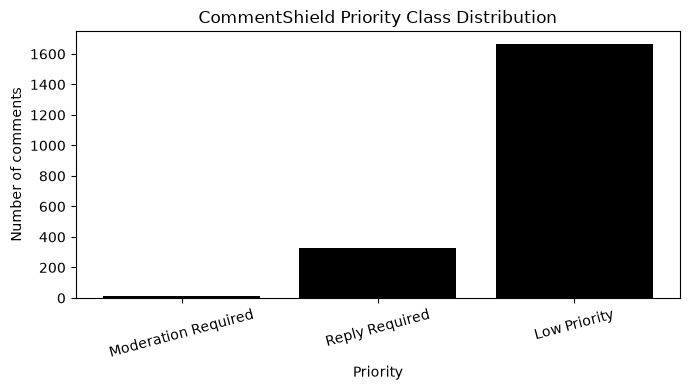

CONFUSION MATRIX - SELECTED MODEL
Selected model: TF-IDF


,Predicted: Moderation Required,Predicted: Reply Required,Predicted: Low Priority
Actual: Moderation Required,7,0,3
Actual: Reply Required,0,288,37
Actual: Low Priority,0,17,1648


PER-CLASS METRICS - SELECTED MODEL


,Priority,Precision,Recall,F1-score,Support
0,Moderation Required,1.0000,0.7000,0.8235,10
1,Reply Required,0.9443,0.8862,0.9143,325
2,Low Priority,0.9763,0.9898,0.9830,1665
3,Macro Average,0.9735,0.8586,0.9069,2000


SIGNAL CONTRIBUTION SUMMARY - ALL 2000 COMMENTS


,Signal,Comments with signal,Percentage,Moderation Required,Reply Required,Low Priority
0,Toxicity,10,0.50,10,0,0
1,Question,170,8.50,3,167,0
2,Request,157,7.85,0,157,0
3,Correction,31,1.55,0,31,0
4,No strong signal,1665,83.25,0,0,1665


In [ ]:
# --- PART 12: GLOBAL INGESTION QUEUE COMPLETE EVALUATION (FULL 2000 COMMENTS) ---
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix

required = [
    "features",
    "ranked_full",
    "LABELS",
    "best_model_name",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run Cells 1-10 first. Missing variables: {missing}")

priority_order = ["Moderation Required", "Reply Required", "Low Priority"]

# 1. Class Distribution (உங்க ஒரிஜினல் டேட்டா கிளாஸ் கவுண்ட்)
class_distribution = (
    features["proxy_label"]
    .value_counts()
    .reindex(priority_order, fill_value=0)
    .rename_axis("Priority")
    .reset_index(name="Comment Count")
)
print("CLASS DISTRIBUTION")
display(class_distribution)

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7, 4))
    plt.bar(class_distribution["Priority"], class_distribution["Comment Count"], color="black")
    plt.title("CommentShield Priority Class Distribution")
    plt.xlabel("Priority")
    plt.ylabel("Number of comments")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
except Exception:
    print("Chart display skipped; the distribution table is available above.")

# Part 10-ல் கணக்கிடப்பட்ட முழு 2,000 கமெண்ட்ஸுக்கான உண்மையான மற்றும் கணிக்கப்பட்ட லேபிள்கள்
y_global_actual = ranked_full["actual_label"].astype(str).to_numpy()
y_global_predicted = ranked_full["predicted_label"].astype(str).to_numpy()

# 2. Confusion Matrix (டெஸ்ட் டேட்டாவுக்குப் பதிலாக முழு 2,000 கமெண்ட்ஸும் இங்கே கணக்கிடப்படும்)
cm = confusion_matrix(y_global_actual, y_global_predicted, labels=priority_order)
confusion_table = pd.DataFrame(
    cm,
    index=[f"Actual: {label}" for label in priority_order],
    columns=[f"Predicted: {label}" for label in priority_order],
)
print("CONFUSION MATRIX - SELECTED MODEL")
print("Selected model:", best_model_name)
display(confusion_table)

# 3. Per-class Precision, Recall and F1 (முழு 2,000 கமெண்ட்ஸுக்கான ஒட்டுமொத்த சராசரி அறிக்கைகள்)
report = classification_report(
    y_global_actual,
    y_global_predicted,
    labels=priority_order,
    output_dict=True,
    zero_division=0,
)
per_class_rows = []
for label in priority_order:
    per_class_rows.append({
        "Priority": label,
        "Precision": round(report[label]["precision"], 4),
        "Recall": round(report[label]["recall"], 4),
        "F1-score": round(report[label]["f1-score"], 4),
        "Support": int(report[label]["support"]),
    })
per_class_rows.append({
    "Priority": "Macro Average",
    "Precision": round(report["macro avg"]["precision"], 4),
    "Recall": round(report["macro avg"]["recall"], 4),
    "F1-score": round(report["macro avg"]["f1-score"], 4),
    "Support": int(report["macro avg"]["support"]),
})
per_class_metrics = pd.DataFrame(per_class_rows)
print("PER-CLASS METRICS - SELECTED MODEL")
display(per_class_metrics)

# 4. Signal Contribution Summary (உங்க சிக்னல் மாஸ்க் லாஜிக் எண்களும் அப்படியே இருக்கும்)
total_comments = len(features)
signal_columns = {
    "Toxicity": "toxicity_score",
    "Question": "question_signal",
    "Request": "request_signal",
    "Correction": "correction_signal",
}
signal_rows = []
for signal_name, column_name in signal_columns.items():
    signal_mask = features[column_name].fillna(0).astype(float) > 0
    priority_counts = (
        features.loc[signal_mask, "proxy_label"]
        .value_counts()
        .reindex(priority_order, fill_value=0)
    )
    signal_rows.append({
        "Signal": signal_name,
        "Comments with signal": int(signal_mask.sum()),
        "Percentage": round(100 * signal_mask.sum() / total_comments, 2),
        "Moderation Required": int(priority_counts["Moderation Required"]),
        "Reply Required": int(priority_counts["Reply Required"]),
        "Low Priority": int(priority_counts["Low Priority"]),
    })

# சிக்னல்கள் ஏதும் இல்லாத சாதாரண கமெண்ட்களின் கணக்கீடு
no_signal_mask = np.ones(total_comments, dtype=bool)
for column_name in signal_columns.values():
    no_signal_mask &= features[column_name].fillna(0).astype(float).to_numpy() <= 0
no_signal_priority_counts = (
    features.loc[no_signal_mask, "proxy_label"]
    .value_counts()
    .reindex(priority_order, fill_value=0)
)
signal_rows.append({
    "Signal": "No strong signal",
    "Comments with signal": int(no_signal_mask.sum()),
    "Percentage": round(100 * no_signal_mask.sum() / total_comments, 2),
    "Moderation Required": int(no_signal_priority_counts["Moderation Required"]),
    "Reply Required": int(no_signal_priority_counts["Reply Required"]),
    "Low Priority": int(no_signal_priority_counts["Low Priority"]),
})
signal_contribution = pd.DataFrame(signal_rows)
print(f"SIGNAL CONTRIBUTION SUMMARY - ALL {total_comments} COMMENTS")
display(signal_contribution)
